# 🌳 Árbol de Decisión — Predicción de HP Pokémon
## Proyecto ETL Pokémon | Minería de Datos | CORHUILA
### Grupo 11 — Nicolas Álvarez & Yeison Scarpeta

---

## 📖 Descripción del Notebook

Este notebook implementa un modelo de **Árbol de Decisión para Regresión** con el objetivo de predecir el **HP (Puntos de Vida)** de los Pokémon a partir de sus características estadísticas.

### 🎯 Variable Objetivo
- **Y (lo que predecimos):** `HP` — Puntos de vida de cada Pokémon

### 📊 Variables Predictoras (Features)
- `Ataque`, `Defensa`, `Ataque Especial`, `Defensa Especial`, `Velocidad`
- `Peso`, `Altura`, `Tasa de Captura`, `Felicidad Base`

### 🔬 Metodología
Entrenamos y evaluamos el árbol con **tres particiones distintas** (80/20, 70/30, 60/40) para demostrar la robustez del modelo.

---

## 🌿 ¿Qué es un Árbol de Decisión para Regresión?

Un árbol de decisión es un modelo de aprendizaje supervisado que aprende una serie de **preguntas binarias** organizadas jerárquicamente para llegar a una predicción.

En **regresión**, el valor predicho es el **promedio de los valores** de las muestras que caen en cada hoja del árbol.

**Ventajas:**
- ✅ Interpretable y visualizable directamente
- ✅ No requiere escalado de variables
- ✅ Captura relaciones no lineales automáticamente

**Desventajas:**
- ⚠️ Sin restricciones puede sobreajustar (overfitting)
- ⚠️ Alta varianza — sensible a cambios en los datos

---

## 📦 Contexto del Proyecto ETL PokeAPI

Este notebook hace parte del proyecto de **Minería de Datos — Grupo 11**, basado en un pipeline ETL que consume información desde la **PokeAPI**.

El flujo general del proyecto es:

1. **Extracción:** se obtienen datos de los Pokémon desde la API.
2. **Transformación:** se limpian y organizan variables como estadísticas, tipos, habilidades, peso, altura y generación.
3. **Carga:** los datos se almacenan en una base de datos PostgreSQL.
4. **Análisis:** se realizan visualizaciones y modelos de Machine Learning.
5. **Modelo:** se implementa un Árbol de Decisión para predecir el HP de los Pokémon.

---

## 🧠 Objetivo del Modelo

El objetivo principal es construir un modelo de regresión capaz de predecir el **HP** de un Pokémon a partir de sus características numéricas.

Este modelo permite responder una pregunta como:

> ¿Es posible estimar los puntos de vida de un Pokémon usando sus estadísticas principales?

Para esto se utiliza el algoritmo `DecisionTreeRegressor` de la librería `scikit-learn`.

In [1]:
# ============================================================
# 1. IMPORTACIONES Y CONFIGURACIÓN INICIAL
# ============================================================

import os
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeRegressor, plot_tree, export_text
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Configuración para poder importar archivos del proyecto
ROOT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(ROOT_DIR))

# Importar conexión a la base de datos del proyecto
from scripts.database import engine

# Crear carpeta para guardar gráficas generadas
SAVE_DIR = ROOT_DIR / "data" / "graficas"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# Configuración visual básica
plt.rcParams.update({
    "figure.dpi": 120,
    "font.size": 10
})

print("✅ Importaciones y configuración inicial listas")
print("📁 Carpeta raíz del proyecto:", ROOT_DIR)
print("📁 Carpeta para gráficas:", SAVE_DIR)

✅ Importaciones y configuración inicial listas
📁 Carpeta raíz del proyecto: /mnt/c/Users/USUARIO/Desktop/Grupo-11-Miner-a-de-datos/Proyecto 11 Pokemon/etl-pokeapi
📁 Carpeta para gráficas: /mnt/c/Users/USUARIO/Desktop/Grupo-11-Miner-a-de-datos/Proyecto 11 Pokemon/etl-pokeapi/data/graficas


---

## 🗄️ Carga de Datos desde PostgreSQL

Los datos que se usan en este notebook provienen de la tabla `pokemon`, la cual fue alimentada previamente por el proceso ETL del proyecto.

Se seleccionan variables numéricas que pueden ayudar a explicar o predecir el valor de `HP`.

### Variables consultadas

- `nombre`
- `altura`
- `peso`
- `experiencia_base`
- `hp`
- `ataque`
- `defensa`
- `ataque_especial`
- `defensa_especial`
- `velocidad`
- `total_movimientos`
- `tasa_captura`
- `felicidad_base`
- `es_legendario`
- `es_mitico`
- `generacion`
- `tipos`

In [2]:
# ============================================================
# 2. CARGA DE DATOS DESDE POSTGRESQL
# ============================================================

QUERY = """
SELECT
    nombre,
    altura,
    peso,
    experiencia_base,
    hp,
    ataque,
    defensa,
    ataque_especial,
    defensa_especial,
    velocidad,
    total_movimientos,
    tasa_captura,
    felicidad_base,
    es_legendario,
    es_mitico,
    generacion,
    tipos
FROM pokemon
WHERE hp IS NOT NULL
ORDER BY id;
"""

df = pd.read_sql(QUERY, engine)

print("✅ Datos cargados correctamente desde PostgreSQL")
print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])

df.head()

✅ Datos cargados correctamente desde PostgreSQL
Filas: 1000
Columnas: 17


,nombre,altura,peso,experiencia_base,hp,ataque,defensa,ataque_especial,defensa_especial,velocidad,total_movimientos,tasa_captura,felicidad_base,es_legendario,es_mitico,generacion,tipos
0,bulbasaur,7,69,64,45,49,49,65,65,45,86,45.0,70.0,False,False,generation-i,"grass, poison"
1,ivysaur,10,130,142,60,62,63,80,80,60,83,45.0,70.0,False,False,generation-i,"grass, poison"
2,venusaur,20,1000,236,80,82,83,100,100,80,96,45.0,70.0,False,False,generation-i,"grass, poison"
3,charmander,6,85,62,39,52,43,60,50,65,105,45.0,70.0,False,False,generation-i,fire
4,charmeleon,11,190,142,58,64,58,80,65,80,103,45.0,70.0,False,False,generation-i,fire


---

## 🔍 Exploración Inicial del Dataset

Antes de entrenar el modelo, se revisa la estructura general de los datos.

En esta parte verificamos:

- Cantidad de registros.
- Tipos de datos.
- Valores nulos.
- Estadísticas descriptivas de las variables numéricas.

Esto es importante porque un modelo de Machine Learning necesita datos limpios y correctamente organizados.

In [3]:
# ============================================================
# 3. EXPLORACIÓN INICIAL
# ============================================================

print("📌 Información general del dataset:")
print(df.info())

print("\n📌 Valores nulos por columna:")
display(df.isnull().sum())

print("\n📌 Estadísticas descriptivas:")
display(df.describe())

📌 Información general del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   nombre             1000 non-null   str    
 1   altura             1000 non-null   int64  
 2   peso               1000 non-null   int64  
 3   experiencia_base   1000 non-null   int64  
 4   hp                 1000 non-null   int64  
 5   ataque             1000 non-null   int64  
 6   defensa            1000 non-null   int64  
 7   ataque_especial    1000 non-null   int64  
 8   defensa_especial   1000 non-null   int64  
 9   velocidad          1000 non-null   int64  
 10  total_movimientos  1000 non-null   int64  
 11  tasa_captura       963 non-null    float64
 12  felicidad_base     963 non-null    float64
 13  es_legendario      1000 non-null   bool   
 14  es_mitico          1000 non-null   bool   
 15  generacion         1000 non-null   str    
 16  t

nombre                0
altura                0
peso                  0
experiencia_base      0
hp                    0
ataque                0
defensa               0
ataque_especial       0
defensa_especial      0
velocidad             0
total_movimientos     0
tasa_captura         37
felicidad_base       37
es_legendario         0
es_mitico             0
generacion            0
tipos                 0
dtype: int64


📌 Estadísticas descriptivas:


,altura,peso,experiencia_base,hp,ataque,defensa,ataque_especial,defensa_especial,velocidad,total_movimientos,tasa_captura,felicidad_base
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,963.000000,963.000000
mean,11.988000,646.321000,148.191000,69.677000,77.04600,71.895000,69.470000,69.667000,66.578000,77.143000,98.784008,61.007269
std,12.461346,1180.510031,76.984018,26.556919,29.71779,29.160424,29.418779,26.563315,28.454588,26.496502,75.968241,21.011900
min,1.000000,1.000000,36.000000,1.000000,5.00000,5.000000,10.000000,20.000000,5.000000,1.000000,3.000000,0.000000
25%,5.000000,85.000000,66.000000,50.000000,55.00000,50.000000,45.000000,50.000000,45.000000,62.000000,45.000000,50.000000
50%,10.000000,280.000000,157.000000,66.000000,75.00000,68.000000,65.000000,65.000000,65.000000,77.000000,60.000000,70.000000
75%,15.000000,657.750000,182.000000,82.000000,100.00000,90.000000,90.000000,85.000000,85.000000,92.250000,150.000000,70.000000
max,200.000000,9999.000000,608.000000,255.000000,181.00000,230.000000,173.000000,230.000000,200.000000,375.000000,255.000000,140.000000


---

## 🧹 Limpieza y Preparación de Datos

En esta etapa se preparan los datos para el modelo.

Como el Árbol de Decisión trabaja con valores numéricos, seleccionamos las columnas numéricas más importantes.

También se realiza una limpieza básica:

- Conversión de columnas a tipo numérico.
- Reemplazo de valores nulos usando la mediana.
- Eliminación de registros sin valor de `HP`.

La mediana se usa porque es menos sensible a valores extremos que el promedio.

In [4]:
# ============================================================
# 4. LIMPIEZA Y PREPARACIÓN DE DATOS
# ============================================================

columnas_numericas = [
    "altura",
    "peso",
    "experiencia_base",
    "ataque",
    "defensa",
    "ataque_especial",
    "defensa_especial",
    "velocidad",
    "total_movimientos",
    "tasa_captura",
    "felicidad_base"
]

# Convertir columnas a valores numéricos por seguridad
for col in columnas_numericas + ["hp"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Reemplazar valores nulos con la mediana de cada columna
df[columnas_numericas] = df[columnas_numericas].fillna(df[columnas_numericas].median())

# Eliminar registros donde HP esté vacío
df = df.dropna(subset=["hp"])

print("✅ Limpieza completada")
print("Filas después de limpieza:", df.shape[0])

print("\n📌 Nulos después de la limpieza:")
display(df[columnas_numericas + ["hp"]].isnull().sum())

✅ Limpieza completada
Filas después de limpieza: 1000

📌 Nulos después de la limpieza:


altura               0
peso                 0
experiencia_base     0
ataque               0
defensa              0
ataque_especial      0
defensa_especial     0
velocidad            0
total_movimientos    0
tasa_captura         0
felicidad_base       0
hp                   0
dtype: int64

---

## 🎯 Definición de Variables del Modelo

Para entrenar el modelo se separan los datos en:

### Variable objetivo

La variable objetivo es:

```text
hp

In [5]:
# ============================================================
# 5. DEFINICIÓN DE X E y
# ============================================================

X = df[columnas_numericas]
y = df["hp"]

print("✅ Variables definidas correctamente")
print("Variables predictoras X:")
print(list(X.columns))

print("\nVariable objetivo y:")
print("hp")

print("\nDimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

✅ Variables definidas correctamente
Variables predictoras X:
['altura', 'peso', 'experiencia_base', 'ataque', 'defensa', 'ataque_especial', 'defensa_especial', 'velocidad', 'total_movimientos', 'tasa_captura', 'felicidad_base']

Variable objetivo y:
hp

Dimensiones de X: (1000, 11)
Dimensiones de y: (1000,)


---

## ✂️ Estrategia de Partición de Datos

Para evaluar el modelo de forma más completa, se usarán tres particiones diferentes:

| Split | Entrenamiento | Prueba |
|---|---:|---:|
| Split 1 | 80% | 20% |
| Split 2 | 70% | 30% |
| Split 3 | 60% | 40% |

La idea es revisar si el modelo mantiene resultados similares aunque cambie el tamaño del conjunto de entrenamiento y prueba.

Si las métricas son parecidas en los tres casos, se puede decir que el modelo es más estable.

---

## 📏 Métricas de Evaluación

Para evaluar el modelo se utilizan cuatro métricas principales:

### R² — Coeficiente de Determinación

Indica qué tanto logra explicar el modelo la variación del HP.

- Un valor cercano a `1` significa mejor rendimiento.
- Un valor cercano a `0` significa que el modelo explica poco.

### MSE — Error Cuadrático Medio

Mide el promedio de los errores elevados al cuadrado.

Penaliza más los errores grandes.

### RMSE — Raíz del Error Cuadrático Medio

Es la raíz del MSE.

Es más fácil de interpretar porque queda en las mismas unidades de la variable objetivo, en este caso puntos de HP.

### MAE — Error Absoluto Medio

Indica cuántos puntos de HP se equivoca el modelo en promedio.

Por ejemplo, si el MAE es 8, significa que el modelo se equivoca aproximadamente por 8 puntos de HP.

In [6]:
# ============================================================
# 6. FUNCIÓN PARA ENTRENAR Y EVALUAR EL MODELO
# ============================================================

resultados_globales = []

def evaluar_split(X, y, test_size, split_label, save_dir):
    """
    Esta función divide los datos, entrena un árbol de decisión,
    calcula métricas y genera gráficas de evaluación.
    """

    # 1. División de datos
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=42
    )

    # 2. Creación y entrenamiento del modelo
    modelo = DecisionTreeRegressor(random_state=42)
    modelo.fit(X_train, y_train)

    # 3. Predicción
    y_pred = modelo.predict(X_test)

    # 4. Cálculo de métricas
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)

    # 5. Guardar resultados
    resultados_globales.append({
        "Split": split_label,
        "Train %": int((1 - test_size) * 100),
        "Test %": int(test_size * 100),
        "R2": r2,
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "Profundidad": modelo.get_depth(),
        "Hojas": modelo.get_n_leaves()
    })

    # 6. Gráfico: Predicción vs Real
    plt.figure(figsize=(8, 5))
    plt.scatter(y_test, y_pred, alpha=0.65)

    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())

    plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
    plt.xlabel("HP real")
    plt.ylabel("HP predicho")
    plt.title(f"Predicción vs Real — {split_label}")
    plt.tight_layout()

    nombre_archivo_1 = f"dt_pokemon_pred_vs_real_{split_label.replace('/', '-').replace(' ', '_')}.png"
    plt.savefig(save_dir / nombre_archivo_1)
    plt.show()

    # 7. Gráfico: Residuos
    residuos = y_test - y_pred

    plt.figure(figsize=(8, 5))
    plt.scatter(y_pred, residuos, alpha=0.65)
    plt.axhline(0, linestyle="--")
    plt.xlabel("HP predicho")
    plt.ylabel("Residuo: HP real - HP predicho")
    plt.title(f"Residuos del modelo — {split_label}")
    plt.tight_layout()

    nombre_archivo_2 = f"dt_pokemon_residuos_{split_label.replace('/', '-').replace(' ', '_')}.png"
    plt.savefig(save_dir / nombre_archivo_2)
    plt.show()

    # 8. Mostrar resultados
    print("=" * 60)
    print(f"✅ RESULTADOS — {split_label}")
    print("=" * 60)
    print(f"R²: {r2:.4f}")
    print(f"MSE: {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"Profundidad del árbol: {modelo.get_depth()}")
    print(f"Número de hojas: {modelo.get_n_leaves()}")

    return modelo, X_train, X_test, y_train, y_test, y_pred

---

## 🌳 Entrenamiento del Modelo — Split 1: 80/20

En esta primera prueba se usa:

- 80% de los datos para entrenamiento.
- 20% de los datos para prueba.

Este es uno de los splits más comunes porque permite entrenar el modelo con una buena cantidad de datos y evaluar con una muestra separada.

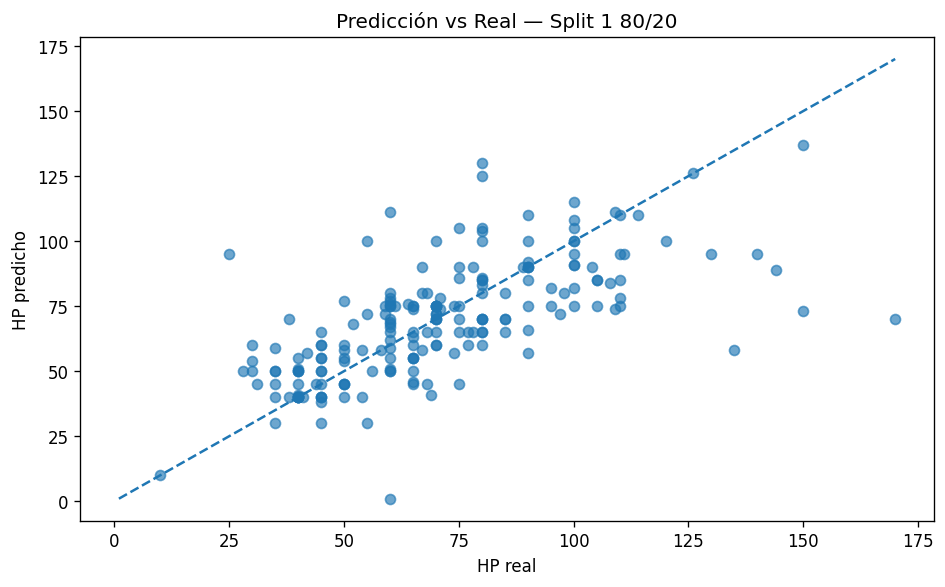

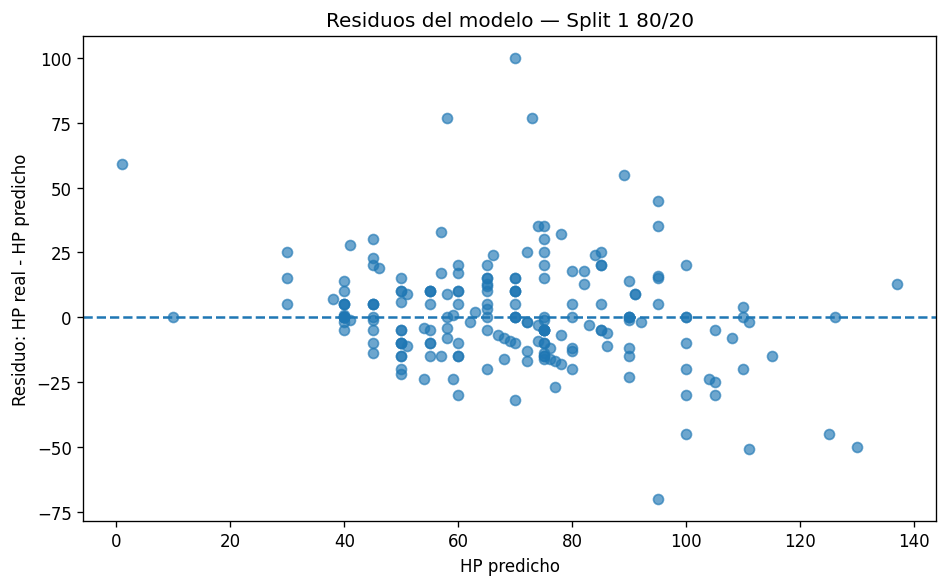

✅ RESULTADOS — Split 1 80/20
R²: 0.4020
MSE: 418.1400
RMSE: 20.4485
MAE: 14.1100
Profundidad del árbol: 23
Número de hojas: 607


In [7]:
# ============================================================
# 7. SPLIT 1 — 80% ENTRENAMIENTO / 20% PRUEBA
# ============================================================

modelo_s1, X_train_s1, X_test_s1, y_train_s1, y_test_s1, y_pred_s1 = evaluar_split(
    X,
    y,
    test_size=0.20,
    split_label="Split 1 80/20",
    save_dir=SAVE_DIR
)

---

## 🌳 Entrenamiento del Modelo — Split 2: 70/30

En esta segunda prueba se usa:

- 70% de los datos para entrenamiento.
- 30% de los datos para prueba.

Este split permite tener un conjunto de prueba más grande, lo que puede dar una evaluación más amplia del rendimiento del modelo.

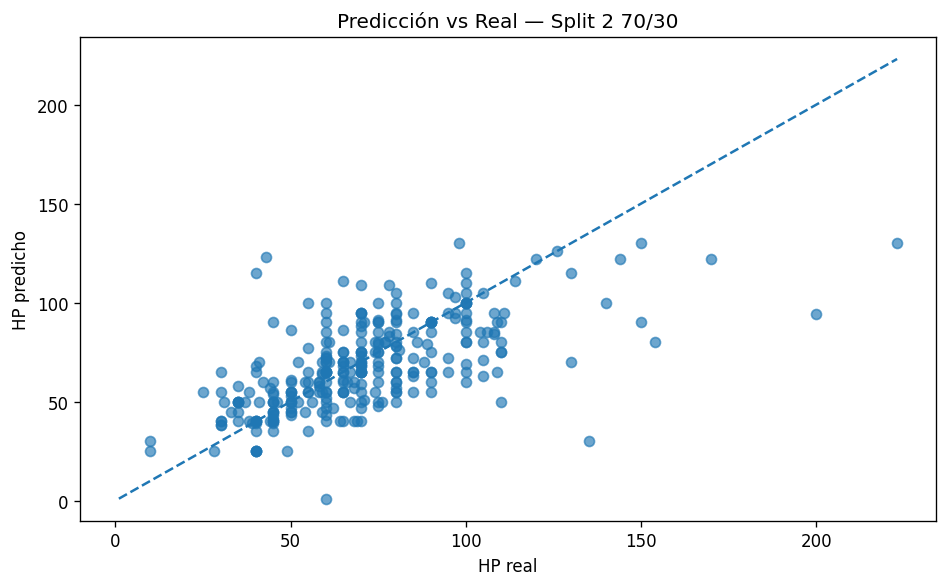

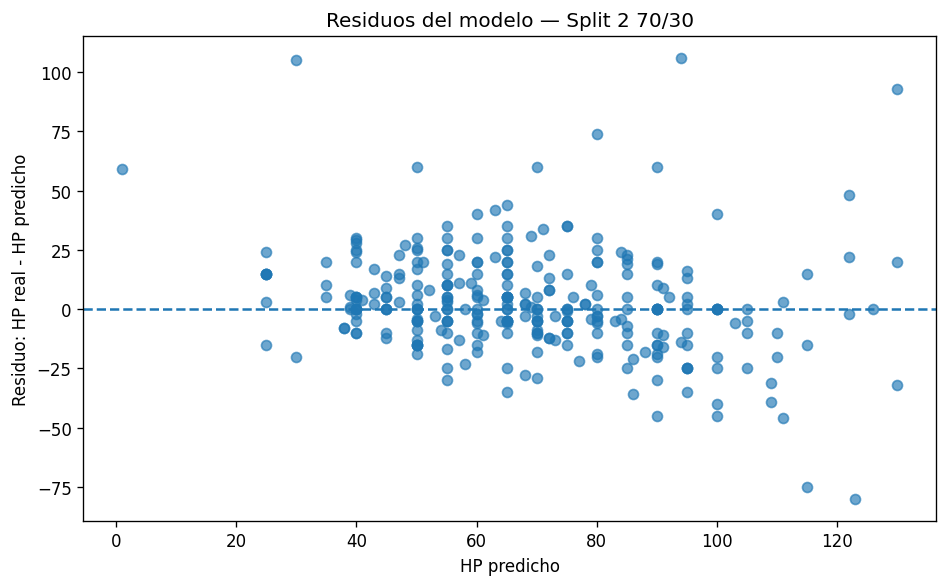

✅ RESULTADOS — Split 2 70/30
R²: 0.3658
MSE: 487.5967
RMSE: 22.0816
MAE: 15.0500
Profundidad del árbol: 23
Número de hojas: 535


In [8]:
# ============================================================
# 8. SPLIT 2 — 70% ENTRENAMIENTO / 30% PRUEBA
# ============================================================

modelo_s2, X_train_s2, X_test_s2, y_train_s2, y_test_s2, y_pred_s2 = evaluar_split(
    X,
    y,
    test_size=0.30,
    split_label="Split 2 70/30",
    save_dir=SAVE_DIR
)

---

## 🌳 Entrenamiento del Modelo — Split 3: 60/40

En esta tercera prueba se usa:

- 60% de los datos para entrenamiento.
- 40% de los datos para prueba.

Este split es más exigente, porque el modelo tiene menos datos para aprender y más datos para ser evaluado.

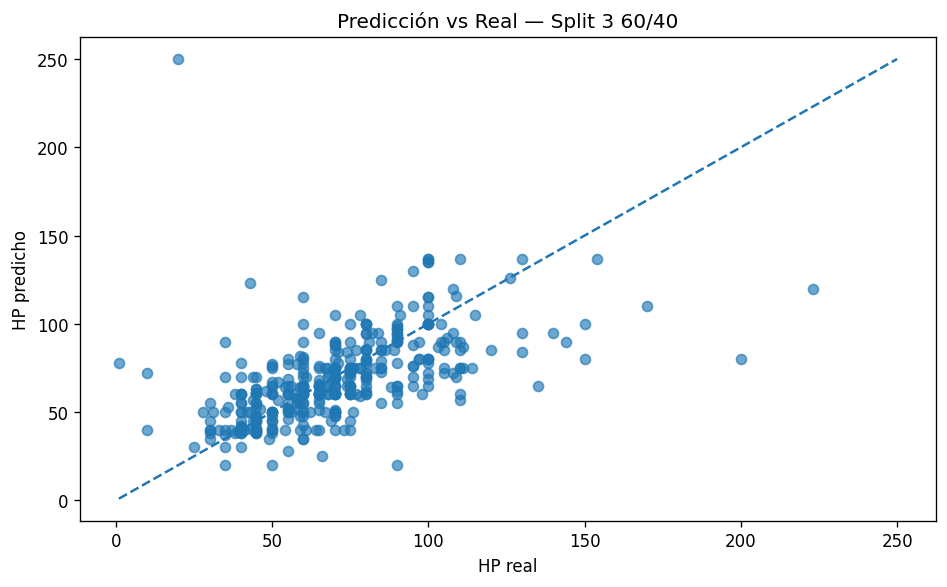

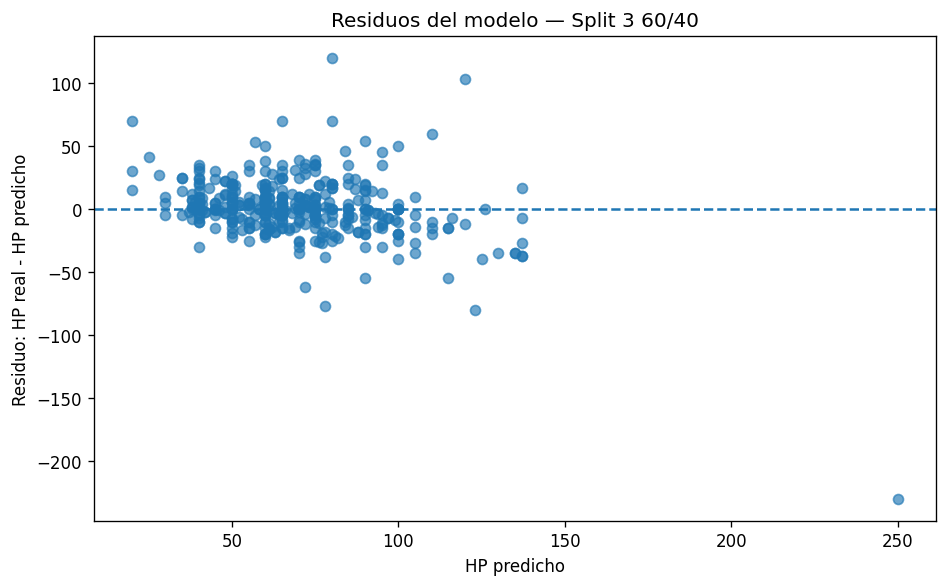

✅ RESULTADOS — Split 3 60/40
R²: 0.1833
MSE: 577.5275
RMSE: 24.0318
MAE: 14.9775
Profundidad del árbol: 19
Número de hojas: 463


In [9]:
# ============================================================
# 9. SPLIT 3 — 60% ENTRENAMIENTO / 40% PRUEBA
# ============================================================

modelo_s3, X_train_s3, X_test_s3, y_train_s3, y_test_s3, y_pred_s3 = evaluar_split(
    X,
    y,
    test_size=0.40,
    split_label="Split 3 60/40",
    save_dir=SAVE_DIR
)

---

## 📊 Comparación de Resultados

Después de entrenar el modelo con tres particiones diferentes, se consolidan las métricas en una tabla.

Esto permite comparar:

- Qué split obtuvo mejor R².
- En cuál split el error fue menor.
- Si el modelo se mantiene estable.
- Si existe una diferencia fuerte entre los resultados.

In [10]:
# ============================================================
# 10. TABLA COMPARATIVA DE MÉTRICAS
# ============================================================

resultados_df = pd.DataFrame(resultados_globales)

resultados_df[["R2", "MSE", "RMSE", "MAE"]] = resultados_df[
    ["R2", "MSE", "RMSE", "MAE"]
].round(4)

resultados_df

,Split,Train %,Test %,R2,MSE,RMSE,MAE,Profundidad,Hojas
0,Split 1 80/20,80,20,0.4020,418.1400,20.4485,14.1100,23,607
1,Split 2 70/30,70,30,0.3658,487.5967,22.0816,15.0500,23,535
2,Split 3 60/40,60,40,0.1833,577.5275,24.0318,14.9775,19,463


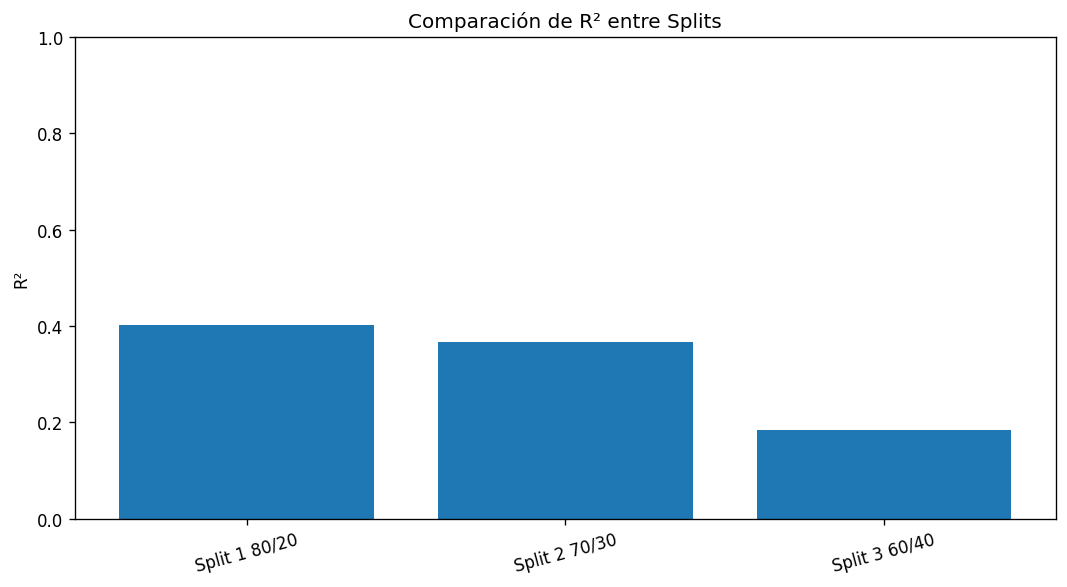

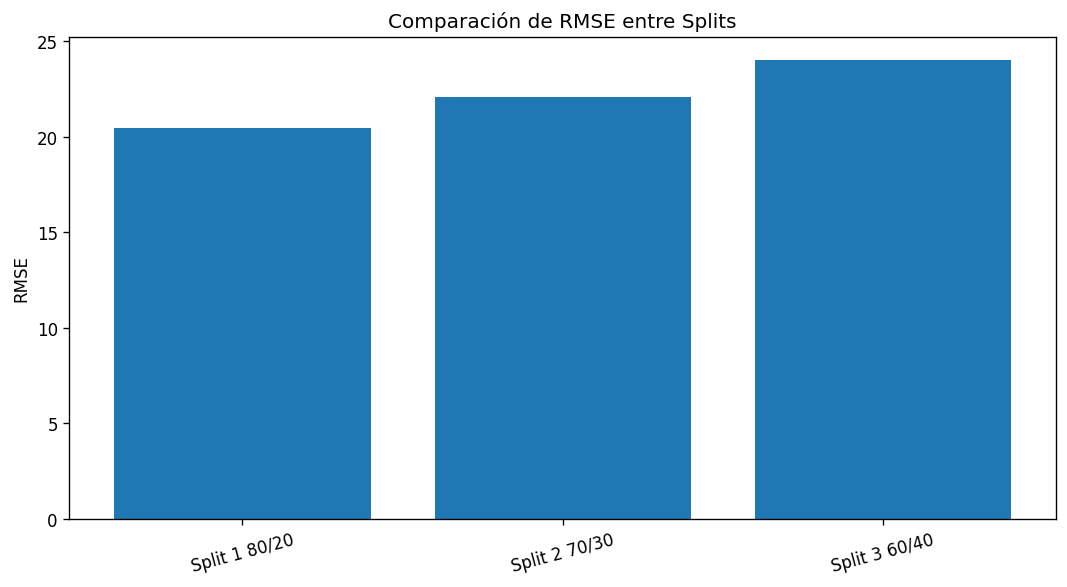

In [11]:
# ============================================================
# 11. GRÁFICAS COMPARATIVAS DE MÉTRICAS
# ============================================================

plt.figure(figsize=(9, 5))
plt.bar(resultados_df["Split"], resultados_df["R2"])
plt.ylim(0, 1)
plt.ylabel("R²")
plt.title("Comparación de R² entre Splits")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(SAVE_DIR / "dt_pokemon_comparativa_r2_splits.png")
plt.show()

plt.figure(figsize=(9, 5))
plt.bar(resultados_df["Split"], resultados_df["RMSE"])
plt.ylabel("RMSE")
plt.title("Comparación de RMSE entre Splits")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(SAVE_DIR / "dt_pokemon_comparativa_rmse_splits.png")
plt.show()

---

## 🔎 Interpretación de la Comparación

Para interpretar los resultados se debe revisar principalmente:

### Si el R² es alto

Un R² alto indica que el modelo logra explicar una buena parte del comportamiento del HP.

### Si el RMSE y MAE son bajos

Un RMSE y MAE bajos indican que el modelo se equivoca poco al predecir el HP.

### Si los tres splits son parecidos

Si los resultados son similares en 80/20, 70/30 y 60/40, significa que el modelo es estable.

### Si los resultados cambian demasiado

Si las métricas varían mucho entre splits, puede significar que el modelo depende demasiado de la forma en que se dividen los datos.

---

## 🌲 Visualización del Árbol Real

El árbol de decisión completo puede ser muy grande, por eso se visualizan solamente los primeros niveles.

Esto permite observar las primeras reglas que el modelo aprende para predecir el HP.

Cada nodo representa una pregunta, por ejemplo:

```text
defensa <= 65.5

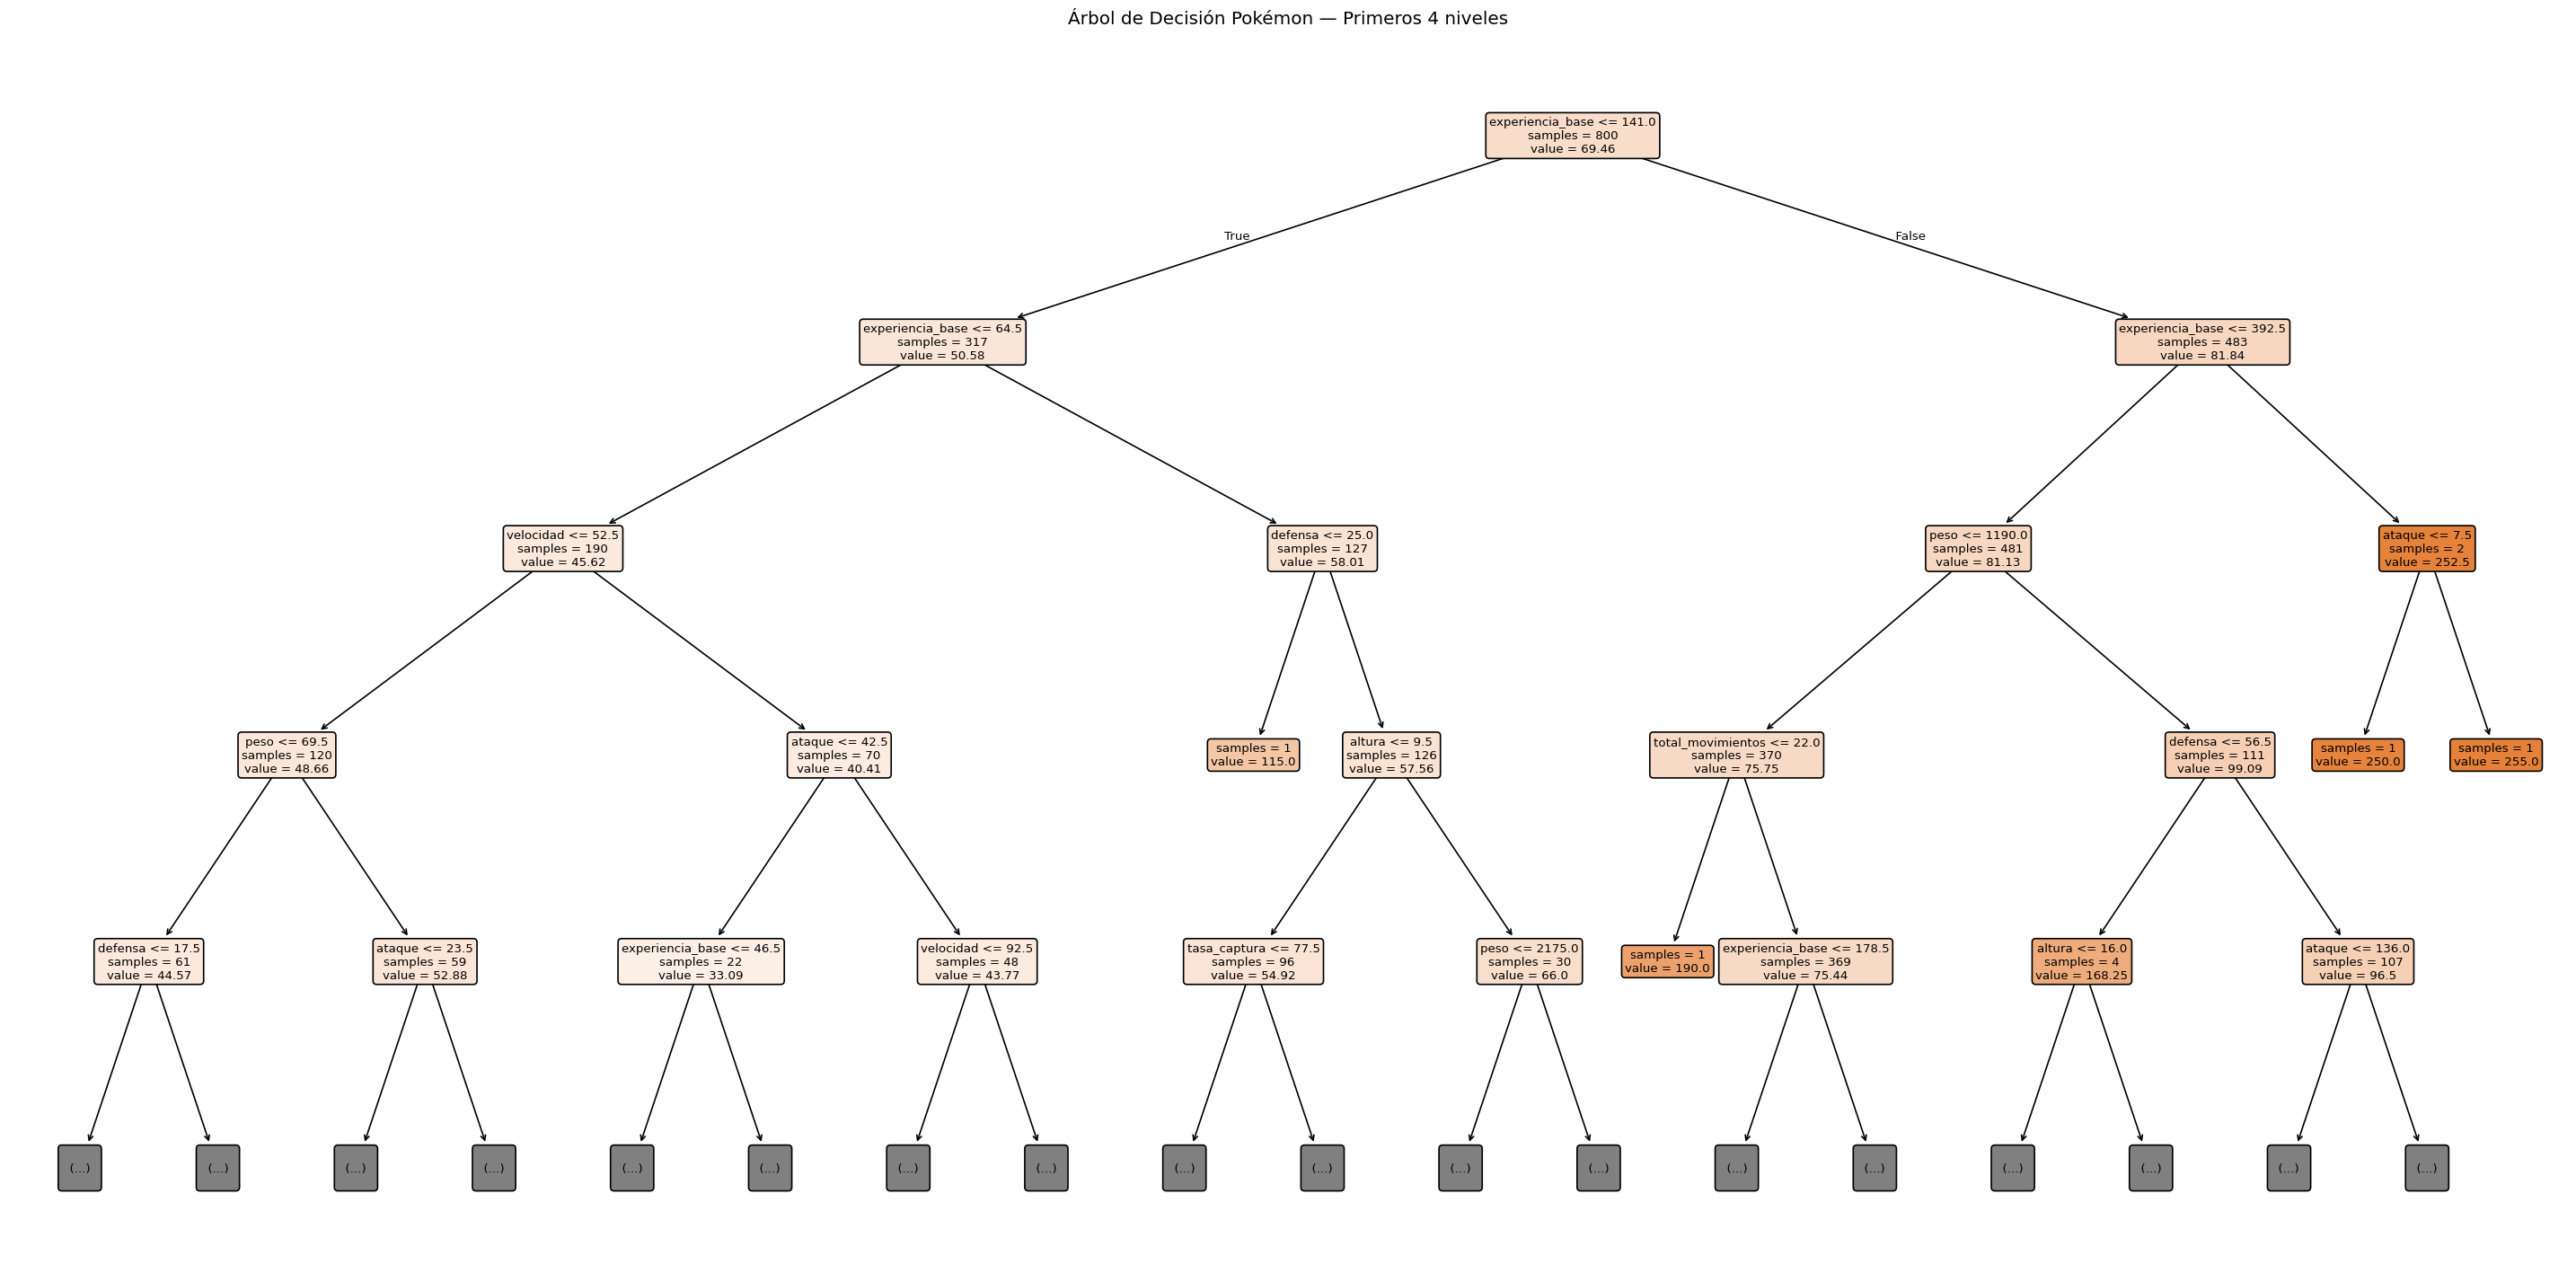

Profundidad total del árbol: 23
Número de hojas: 607


In [13]:
# ============================================================
# 12. VISUALIZACIÓN DEL ÁRBOL REAL — PRIMEROS 4 NIVELES
# ============================================================

plt.figure(figsize=(24, 12))

plot_tree(
    modelo_s1,
    max_depth=4,
    feature_names=list(X.columns),
    filled=True,
    rounded=True,
    impurity=False,
    precision=2,
    fontsize=8
)

plt.title("Árbol de Decisión Pokémon — Primeros 4 niveles")
plt.tight_layout()
plt.savefig(SAVE_DIR / "dt_pokemon_arbol_real_4niveles.png")
plt.show()

print("Profundidad total del árbol:", modelo_s1.get_depth())
print("Número de hojas:", modelo_s1.get_n_leaves())

---

## 🌱 Árbol Pedagógico con Profundidad Máxima 3

Para explicar mejor el funcionamiento del árbol, se entrena un segundo modelo más pequeño usando:

```python
max_depth=3

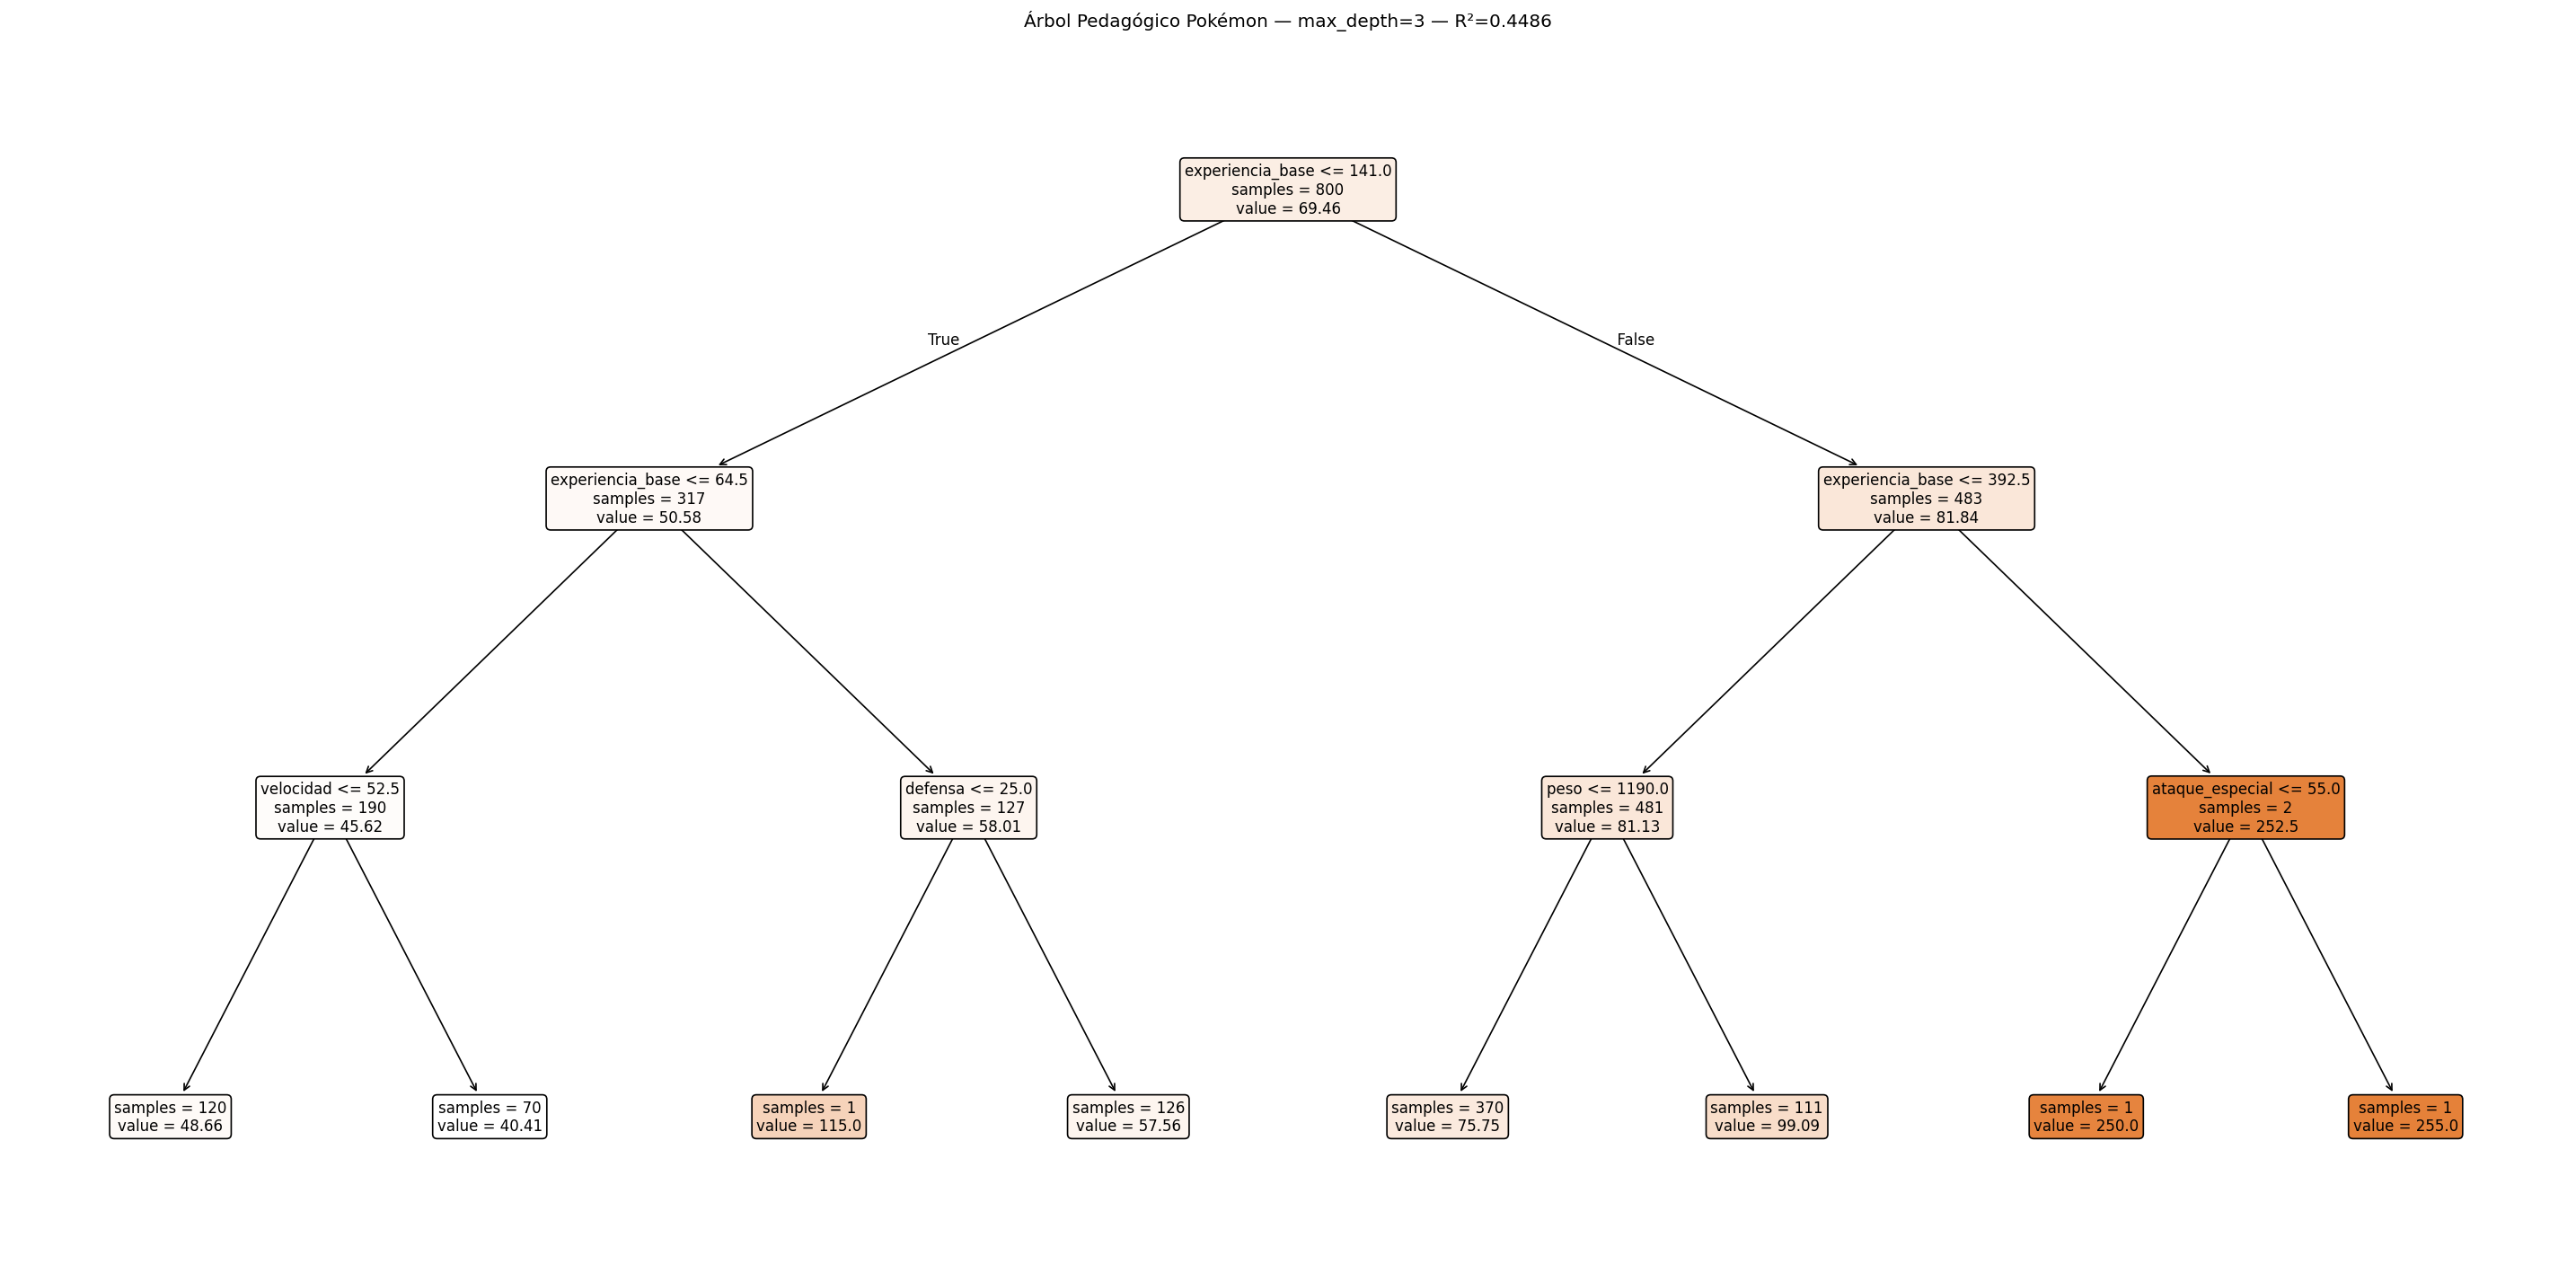

✅ Métricas del árbol pedagógico
R²: 0.4486
MSE: 385.5856
RMSE: 19.6363
MAE: 13.5979
Profundidad: 3
Hojas: 8


In [14]:
# ============================================================
# 13. ÁRBOL PEDAGÓGICO — max_depth=3
# ============================================================

modelo_viz = DecisionTreeRegressor(max_depth=3, random_state=42)
modelo_viz.fit(X_train_s1, y_train_s1)

y_pred_viz = modelo_viz.predict(X_test_s1)

r2_viz = r2_score(y_test_s1, y_pred_viz)
mse_viz = mean_squared_error(y_test_s1, y_pred_viz)
rmse_viz = np.sqrt(mse_viz)
mae_viz = mean_absolute_error(y_test_s1, y_pred_viz)

plt.figure(figsize=(24, 12))

plot_tree(
    modelo_viz,
    feature_names=list(X.columns),
    filled=True,
    rounded=True,
    impurity=False,
    precision=2,
    fontsize=10
)

plt.title(f"Árbol Pedagógico Pokémon — max_depth=3 — R²={r2_viz:.4f}")
plt.tight_layout()
plt.savefig(SAVE_DIR / "dt_pokemon_arbol_pedagogico_depth3.png")
plt.show()

print("✅ Métricas del árbol pedagógico")
print(f"R²: {r2_viz:.4f}")
print(f"MSE: {mse_viz:.4f}")
print(f"RMSE: {rmse_viz:.4f}")
print(f"MAE: {mae_viz:.4f}")
print("Profundidad:", modelo_viz.get_depth())
print("Hojas:", modelo_viz.get_n_leaves())

---

## 📜 Reglas del Árbol en Texto

Además de visualizar el árbol como imagen, también se pueden extraer sus reglas en texto usando `export_text`.

Esto es útil porque permite leer las decisiones del modelo en forma de condiciones.

Por ejemplo:

```text
|--- defensa <= 65.50
|   |--- ataque <= 48.00
|   |   |--- value: [45.00]

In [15]:
# ============================================================
# 14. EXPORTAR REGLAS DEL ÁRBOL PEDAGÓGICO
# ============================================================

reglas = export_text(modelo_viz, feature_names=list(X.columns))

print(reglas)

# Guardar reglas en archivo .txt
ruta_reglas = SAVE_DIR / "dt_pokemon_reglas_arbol.txt"

with open(ruta_reglas, "w", encoding="utf-8") as f:
    f.write(reglas)

print("✅ Reglas guardadas en:", ruta_reglas)

|--- experiencia_base <= 141.00
|   |--- experiencia_base <= 64.50
|   |   |--- velocidad <= 52.50
|   |   |   |--- value: [48.66]
|   |   |--- velocidad >  52.50
|   |   |   |--- value: [40.41]
|   |--- experiencia_base >  64.50
|   |   |--- defensa <= 25.00
|   |   |   |--- value: [115.00]
|   |   |--- defensa >  25.00
|   |   |   |--- value: [57.56]
|--- experiencia_base >  141.00
|   |--- experiencia_base <= 392.50
|   |   |--- peso <= 1190.00
|   |   |   |--- value: [75.75]
|   |   |--- peso >  1190.00
|   |   |   |--- value: [99.09]
|   |--- experiencia_base >  392.50
|   |   |--- ataque_especial <= 55.00
|   |   |   |--- value: [250.00]
|   |   |--- ataque_especial >  55.00
|   |   |   |--- value: [255.00]

✅ Reglas guardadas en: /mnt/c/Users/USUARIO/Desktop/Grupo-11-Miner-a-de-datos/Proyecto 11 Pokemon/etl-pokeapi/data/graficas/dt_pokemon_reglas_arbol.txt


---

## ⭐ Importancia de Variables

El árbol de decisión permite identificar cuáles variables fueron más importantes para predecir el HP.

Una variable con mayor importancia significa que el modelo la usó más o que ayudó más a reducir el error durante las divisiones.

Esto permite responder preguntas como:

- ¿El peso influye en el HP?
- ¿La defensa ayuda a predecir los puntos de vida?
- ¿La experiencia base es importante para el modelo?

,Variable,Importancia
2,experiencia_base,0.515148
1,peso,0.127227
4,defensa,0.083095
8,total_movimientos,0.048858
0,altura,0.048478
3,ataque,0.044576
7,velocidad,0.041782
6,defensa_especial,0.037393
5,ataque_especial,0.032898
9,tasa_captura,0.018416


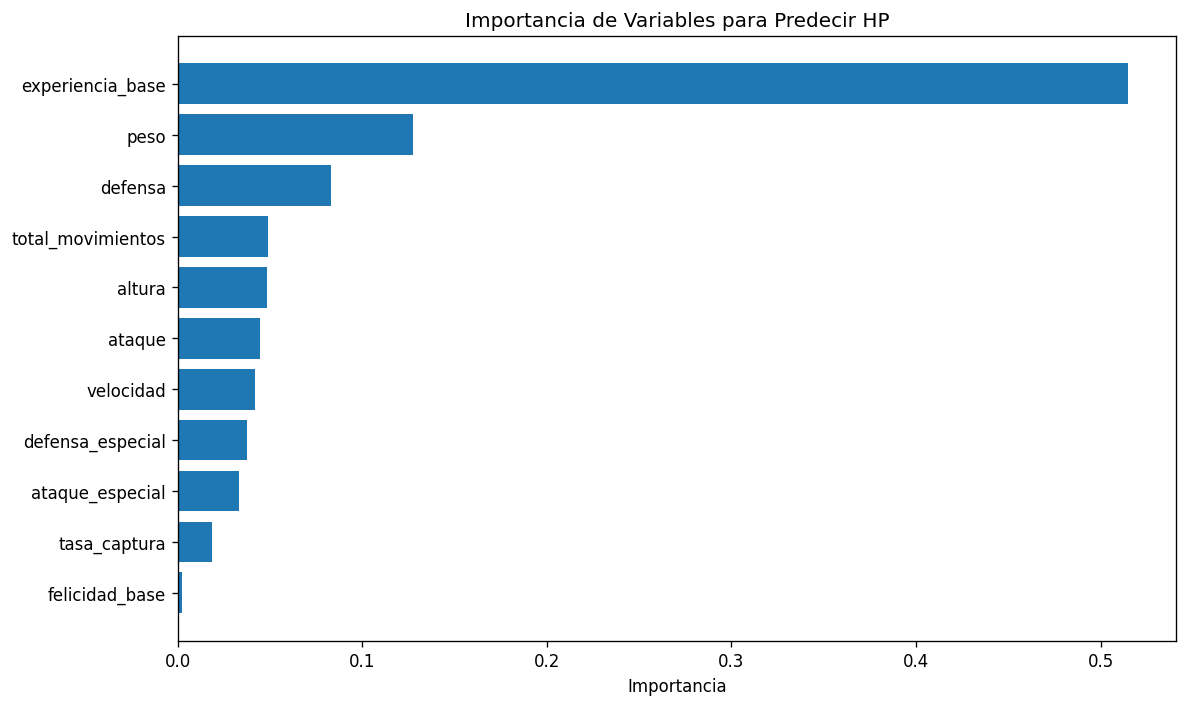

In [16]:
# ============================================================
# 15. IMPORTANCIA DE VARIABLES
# ============================================================

importancias = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": modelo_s1.feature_importances_
}).sort_values(by="Importancia", ascending=False)

display(importancias)

plt.figure(figsize=(10, 6))
plt.barh(importancias["Variable"], importancias["Importancia"])
plt.gca().invert_yaxis()
plt.xlabel("Importancia")
plt.title("Importancia de Variables para Predecir HP")
plt.tight_layout()
plt.savefig(SAVE_DIR / "dt_pokemon_importancia_variables.png")
plt.show()

---

## ⚠️ Overfitting en Árboles de Decisión

El **overfitting** o sobreajuste ocurre cuando el modelo aprende demasiado los datos de entrenamiento, pero pierde capacidad para generalizar con datos nuevos.

En los árboles de decisión esto puede pasar cuando:

- El árbol crece demasiado.
- Tiene demasiada profundidad.
- Tiene demasiadas hojas.
- Aprende detalles muy específicos del conjunto de entrenamiento.

Por eso es importante revisar:

- La profundidad del árbol.
- El número de hojas.
- Las diferencias entre las métricas de los tres splits.
- El rendimiento del árbol pedagógico frente al árbol completo.

Un árbol más pequeño puede ser menos preciso, pero más fácil de explicar y menos propenso al sobreajuste.

---

## 🔧 Mejora del Modelo con GridSearchCV

Para mejorar el modelo se puede usar `GridSearchCV`.

Esta técnica prueba diferentes combinaciones de hiperparámetros y selecciona la mejor configuración.

Los hiperparámetros evaluados son:

- `max_depth`: profundidad máxima del árbol.
- `min_samples_leaf`: mínimo de muestras por hoja.
- `min_samples_split`: mínimo de muestras necesarias para dividir un nodo.

Esto ayuda a encontrar un árbol más equilibrado, evitando que sea demasiado grande o complejo.

In [17]:
# ============================================================
# 16. BÚSQUEDA DE MEJORES HIPERPARÁMETROS CON GridSearchCV
# ============================================================

param_grid = {
    "max_depth": [3, 4, 5, 6, 8, 10, None],
    "min_samples_leaf": [1, 3, 5, 10, 20],
    "min_samples_split": [2, 5, 10, 20]
}

grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train_s1, y_train_s1)

mejor_modelo = grid.best_estimator_
y_pred_grid = mejor_modelo.predict(X_test_s1)

r2_grid = r2_score(y_test_s1, y_pred_grid)
mse_grid = mean_squared_error(y_test_s1, y_pred_grid)
rmse_grid = np.sqrt(mse_grid)
mae_grid = mean_absolute_error(y_test_s1, y_pred_grid)

print("✅ Mejores hiperparámetros encontrados:")
print(grid.best_params_)

print("\n📊 Resultados del modelo optimizado:")
print(f"R² validación cruzada: {grid.best_score_:.4f}")
print(f"R² test: {r2_grid:.4f}")
print(f"MSE test: {mse_grid:.4f}")
print(f"RMSE test: {rmse_grid:.4f}")
print(f"MAE test: {mae_grid:.4f}")
print("Profundidad:", mejor_modelo.get_depth())
print("Hojas:", mejor_modelo.get_n_leaves())

✅ Mejores hiperparámetros encontrados:
{'max_depth': 5, 'min_samples_leaf': 20, 'min_samples_split': 2}

📊 Resultados del modelo optimizado:
R² validación cruzada: 0.4466
R² test: 0.4505
MSE test: 384.2333
RMSE test: 19.6019
MAE test: 13.5656
Profundidad: 5
Hojas: 20


---

## 🧪 Comparación entre Árbol Completo, Árbol Pedagógico y Árbol Optimizado

En esta parte se comparan tres versiones del modelo:

1. **Árbol completo:** se entrena sin limitar la profundidad.
2. **Árbol pedagógico:** se limita con `max_depth=3` para facilitar la explicación.
3. **Árbol optimizado:** usa los mejores hiperparámetros encontrados con `GridSearchCV`.

Esta comparación permite analizar si vale la pena usar un árbol más complejo o si un árbol más sencillo ofrece resultados aceptables.

In [18]:
# ============================================================
# 17. COMPARACIÓN DE MODELOS
# ============================================================

comparacion_modelos = pd.DataFrame([
    {
        "Modelo": "Árbol completo",
        "R2": resultados_df.loc[0, "R2"],
        "RMSE": resultados_df.loc[0, "RMSE"],
        "MAE": resultados_df.loc[0, "MAE"],
        "Profundidad": modelo_s1.get_depth(),
        "Hojas": modelo_s1.get_n_leaves()
    },
    {
        "Modelo": "Árbol pedagógico max_depth=3",
        "R2": round(r2_viz, 4),
        "RMSE": round(rmse_viz, 4),
        "MAE": round(mae_viz, 4),
        "Profundidad": modelo_viz.get_depth(),
        "Hojas": modelo_viz.get_n_leaves()
    },
    {
        "Modelo": "Árbol optimizado GridSearchCV",
        "R2": round(r2_grid, 4),
        "RMSE": round(rmse_grid, 4),
        "MAE": round(mae_grid, 4),
        "Profundidad": mejor_modelo.get_depth(),
        "Hojas": mejor_modelo.get_n_leaves()
    }
])

comparacion_modelos

,Modelo,R2,RMSE,MAE,Profundidad,Hojas
0,Árbol completo,0.4020,20.4485,14.1100,23,607
1,Árbol pedagógico max_depth=3,0.4486,19.6363,13.5979,3,8
2,Árbol optimizado GridSearchCV,0.4505,19.6019,13.5656,5,20


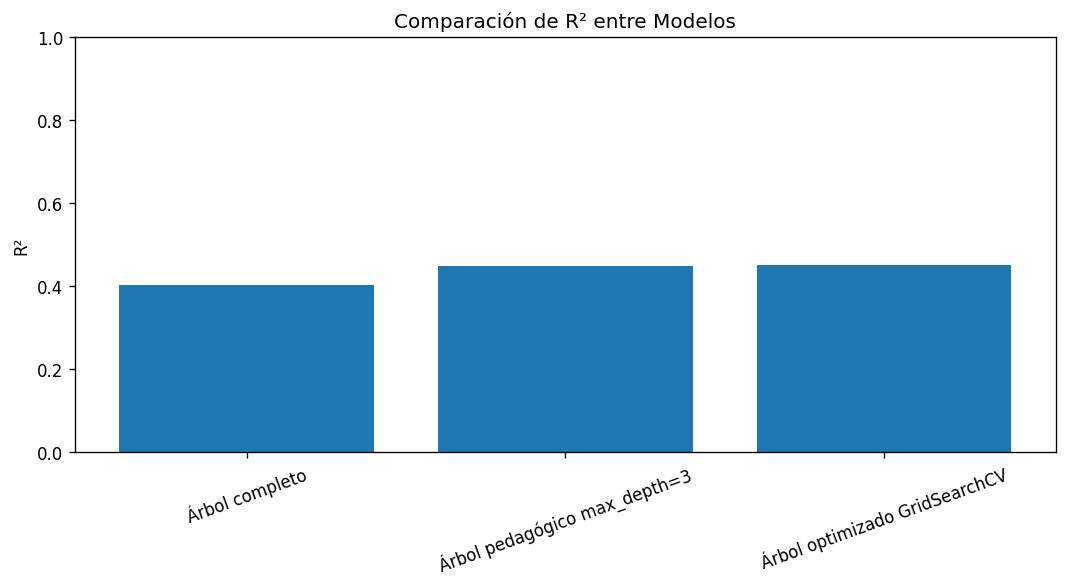

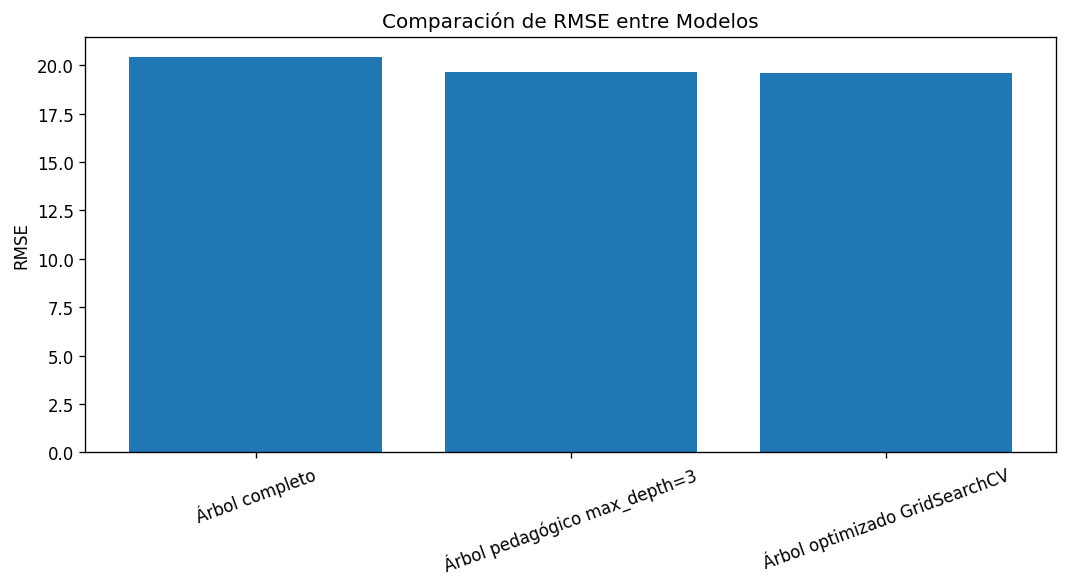

In [19]:
# ============================================================
# 18. GRÁFICA DE COMPARACIÓN DE MODELOS
# ============================================================

plt.figure(figsize=(9, 5))
plt.bar(comparacion_modelos["Modelo"], comparacion_modelos["R2"])
plt.ylim(0, 1)
plt.ylabel("R²")
plt.title("Comparación de R² entre Modelos")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(SAVE_DIR / "dt_pokemon_comparacion_modelos_r2.png")
plt.show()

plt.figure(figsize=(9, 5))
plt.bar(comparacion_modelos["Modelo"], comparacion_modelos["RMSE"])
plt.ylabel("RMSE")
plt.title("Comparación de RMSE entre Modelos")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(SAVE_DIR / "dt_pokemon_comparacion_modelos_rmse.png")
plt.show()

---

## 📌 Interpretación Final del Modelo

Después de entrenar y evaluar el árbol de decisión, se puede concluir que este modelo es útil para analizar la relación entre las estadísticas de los Pokémon y su HP.

El modelo no solo entrega una predicción, sino que también permite interpretar el proceso mediante:

- Gráficas del árbol.
- Reglas de decisión.
- Importancia de variables.
- Comparación de métricas.

Esto lo convierte en un modelo adecuado para un proyecto académico de minería de datos, porque combina predicción e interpretación.

---

## ✅ Conclusiones

1. Se implementó un modelo de **Árbol de Decisión para Regresión** usando `DecisionTreeRegressor`.

2. La variable objetivo del modelo fue el **HP** de los Pokémon.

3. Las variables predictoras fueron estadísticas como ataque, defensa, velocidad, peso, altura, experiencia base, tasa de captura y felicidad base.

4. Se evaluó el modelo usando tres particiones diferentes: 80/20, 70/30 y 60/40.

5. Las métricas utilizadas fueron **R², MSE, RMSE y MAE**, lo que permitió analizar el rendimiento del modelo desde diferentes puntos de vista.

6. El árbol completo puede tener buen rendimiento, pero también puede presentar riesgo de sobreajuste si crece demasiado.

7. El árbol pedagógico con `max_depth=3` facilita la explicación del modelo, ya que muestra reglas más simples y fáciles de interpretar.

8. Con `GridSearchCV` se buscó una configuración más equilibrada del modelo, ajustando hiperparámetros como profundidad máxima, muestras mínimas por hoja y muestras mínimas para dividir un nodo.

9. La importancia de variables permitió identificar qué características tienen mayor peso en la predicción del HP.

10. Este análisis fortalece el proyecto ETL PokeAPI porque agrega una capa de Machine Learning supervisado e interpretación de datos.